# E-Ticaret Siparişlerinde Düşük Müşteri Memnuniyeti Tahmini ve Finansal Fayda Simülasyonu

## Projenin Amacı

Bu projenin amacı, e-ticaret siparişlerinde düşük müşteri memnuniyeti riski taşıyan siparişleri makine öğrenmesi yöntemleriyle tahmin etmek ve bu tahminlerin işletmeye sağlayacağı finansal katkıyı analiz etmektir.

Çalışmada Olist e-ticaret veri setindeki sipariş, müşteri, ödeme, ürün, teslimat ve yorum verileri birleştirilmiştir. Ayrıca sipariş tarihleri kampanya/ticari takvim verisiyle zenginleştirilerek veri harmanlama yapılmıştır.

Modelin hedef değişkeni, müşterinin sipariş sonrası 1 veya 2 yıldız vermesi olarak tanımlanan düşük müşteri memnuniyetidir.

Bu proje kapsamında yalnızca teknik model başarısı değil, aynı zamanda modelin şirket için yaratacağı finansal değer de ölçülmüştür.

In [ ]:
import os

csv_dosyalari = [dosya for dosya in os.listdir("/") if dosya.endswith(".csv")]
csv_dosyalari

In [ ]:
import pandas as pd

orders = pd.read_csv("/olist_orders_dataset.csv")
reviews = pd.read_csv("/olist_order_reviews_dataset.csv")
payments = pd.read_csv("/olist_order_payments_dataset.csv")
items = pd.read_csv("/olist_order_items_dataset.csv")
customers = pd.read_csv("/olist_customers_dataset.csv")
products = pd.read_csv("/olist_products_dataset.csv")

In [ ]:
print("Orders:", orders.shape)
print("Reviews:", reviews.shape)
print("Payments:", payments.shape)
print("Items:", items.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)

In [ ]:
orders.head()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [ ]:
orders = pd.read_csv("/olist_orders_dataset.csv")
reviews = pd.read_csv("/olist_order_reviews_dataset.csv")
payments = pd.read_csv("/olist_order_payments_dataset.csv")
items = pd.read_csv("/olist_order_items_dataset.csv")
customers = pd.read_csv("/olist_customers_dataset.csv")
products = pd.read_csv("/olist_products_dataset.csv")
sellers = pd.read_csv("/olist_sellers_dataset.csv")
category_translation = pd.read_csv("/product_category_name_translation.csv")


In [ ]:
print("Orders:", orders.shape)
print("Reviews:", reviews.shape)
print("Payments:", payments.shape)
print("Items:", items.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)
print("Category Translation:", category_translation.shape)


In [ ]:
orders.head()

In [ ]:
reviews.head()

In [ ]:
print("ORDERS:")
print(orders.columns)

print("\nREVIEWS:")
print(reviews.columns)

print("\nPAYMENTS:")
print(payments.columns)

print("\nITEMS:")
print(items.columns)

print("\nCUSTOMERS:")
print(customers.columns)

print("\nPRODUCTS:")
print(products.columns)

In [ ]:
df = orders.merge(reviews, on="order_id", how="left")

df.shape

In [ ]:
df = df.merge(payments, on="order_id", how="left")

df.shape

In [ ]:
df = df.merge(items, on="order_id", how="left")

df.shape

In [ ]:
df = df.merge(customers, on="customer_id", how="left")

df.shape

In [ ]:
df = df.merge(products, on="product_id", how="left")

df.shape

In [ ]:
df = df.merge(category_translation, on="product_category_name", how="left")

df.shape

In [ ]:
df.head()


In [ ]:
df.info()

In [ ]:
df["low_satisfaction"] = df["review_score"].apply(lambda x: 1 if x <= 2 else 0)

df[["review_score", "low_satisfaction"]].head(10)

In [ ]:
df["low_satisfaction"].value_counts()

In [ ]:
df["low_satisfaction"].value_counts(normalize=True) * 100

In [ ]:
df.head()

In [ ]:
df["low_satisfaction"].value_counts()

In [ ]:
payments_agg = payments.groupby("order_id").agg({
    "payment_sequential": "max",
    "payment_installments": "max",
    "payment_value": "sum"
}).reset_index()

payments_agg.head()

In [ ]:
items_agg = items.groupby("order_id").agg({
    "order_item_id": "count",
    "product_id": "first",
    "seller_id": "nunique",
    "price": "sum",
    "freight_value": "sum"
}).reset_index()

items_agg = items_agg.rename(columns={
    "order_item_id": "item_count",
    "seller_id": "seller_count",
    "price": "total_product_price",
    "freight_value": "total_freight_value"
})

items_agg.head()

In [ ]:
reviews_agg = reviews.groupby("order_id").agg({
    "review_score": "mean",
    "review_comment_message": lambda x: " ".join(x.dropna().astype(str))
}).reset_index()

reviews_agg.head()

## Veri Kaynakları ve Veri Harmanlama

Bu çalışmada tek bir hazır CSV dosyası kullanılmamıştır. Sipariş, müşteri, ürün, ödeme, sipariş kalemleri ve müşteri yorumları gibi farklı veri tabloları `order_id`, `customer_id` ve `product_id` alanları üzerinden birleştirilmiştir.

Kullanılan ana veri kaynakları şunlardır:

- Sipariş verileri
- Müşteri verileri
- Ürün verileri
- Ödeme verileri
- Sipariş kalemi verileri
- Müşteri yorumları ve puanları
- Kampanya / ticari takvim verisi

Bu yapı sayesinde proje, klasik tek tablo modellemesinin ötesine geçerek veri harmanlama yaklaşımını kullanmaktadır.

In [ ]:
main_df = orders.merge(reviews_agg, on="order_id", how="left")
main_df = main_df.merge(payments_agg, on="order_id", how="left")
main_df = main_df.merge(items_agg, on="order_id", how="left")
main_df = main_df.merge(customers, on="customer_id", how="left")
main_df = main_df.merge(products, on="product_id", how="left")
main_df = main_df.merge(category_translation, on="product_category_name", how="left")

main_df.head()

In [ ]:
main_df.shape

In [ ]:
main_df.columns

In [ ]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    main_df[col] = pd.to_datetime(main_df[col], errors="coerce")

In [ ]:
main_df["low_satisfaction"] = main_df["review_score"].apply(lambda x: 1 if x <= 2 else 0)

main_df[["review_score", "low_satisfaction"]].head(10)

In [ ]:
main_df["low_satisfaction"].value_counts()

In [ ]:
main_df["low_satisfaction"].value_counts(normalize=True) * 100

## İş Mantığına Dayalı Özellik Mühendisliği

Ham veri setindeki değişkenlere ek olarak, işletme problemiyle doğrudan ilişkili yeni değişkenler oluşturulmuştur.

Oluşturulan bazı değişkenler:

- `actual_delivery_days`: Siparişin kaç günde teslim edildiğini gösterir.
- `delivery_delay_days`: Teslimatın tahmini tarihe göre kaç gün geciktiğini gösterir.
- `is_late_delivery`: Siparişin geç teslim edilip edilmediğini belirtir.
- `freight_ratio`: Kargo ücretinin ürün fiyatına oranını gösterir.
- `high_installment`: Siparişte yüksek taksit kullanılıp kullanılmadığını gösterir.
- `is_weekend`: Siparişin hafta sonu verilip verilmediğini gösterir.
- `review_text_length`: Müşteri yorum metninin uzunluğunu gösterir.

Bu değişkenler, müşteri memnuniyetsizliğini yalnızca ham verilerle değil, işletme mantığına dayalı risk göstergeleriyle açıklamayı amaçlamaktadır.

In [ ]:
main_df["actual_delivery_days"] = (
    main_df["order_delivered_customer_date"] - main_df["order_purchase_timestamp"]
).dt.days

main_df["estimated_delivery_days"] = (
    main_df["order_estimated_delivery_date"] - main_df["order_purchase_timestamp"]
).dt.days

main_df["delivery_delay_days"] = (
    main_df["order_delivered_customer_date"] - main_df["order_estimated_delivery_date"]
).dt.days

main_df["is_late_delivery"] = main_df["delivery_delay_days"].apply(lambda x: 1 if x > 0 else 0)

main_df[[
    "actual_delivery_days",
    "estimated_delivery_days",
    "delivery_delay_days",
    "is_late_delivery"
]].head()

In [ ]:
main_df["total_order_value"] = main_df["total_product_price"] + main_df["total_freight_value"]

main_df["freight_ratio"] = main_df["total_freight_value"] / (main_df["total_product_price"] + 1)

main_df["high_installment"] = main_df["payment_installments"].apply(lambda x: 1 if x >= 6 else 0)

main_df[[
    "total_product_price",
    "total_freight_value",
    "total_order_value",
    "freight_ratio",
    "payment_installments",
    "high_installment"
]].head()

In [ ]:
main_df["order_month"] = main_df["order_purchase_timestamp"].dt.month
main_df["order_dayofweek"] = main_df["order_purchase_timestamp"].dt.dayofweek
main_df["is_weekend"] = main_df["order_dayofweek"].apply(lambda x: 1 if x >= 5 else 0)

main_df[[
    "order_month",
    "order_dayofweek",
    "is_weekend"
]].head()

In [ ]:
main_df["review_comment_message"] = main_df["review_comment_message"].fillna("")

main_df["review_text_length"] = main_df["review_comment_message"].apply(len)

main_df["has_review_comment"] = main_df["review_text_length"].apply(lambda x: 1 if x > 0 else 0)

main_df[[
    "review_comment_message",
    "review_text_length",
    "has_review_comment"
]].head()

In [ ]:
new_features = [
    "actual_delivery_days",
    "estimated_delivery_days",
    "delivery_delay_days",
    "is_late_delivery",
    "total_order_value",
    "freight_ratio",
    "high_installment",
    "order_month",
    "order_dayofweek",
    "is_weekend",
    "review_text_length",
    "has_review_comment"
]

main_df[new_features].head()

In [ ]:
main_df[new_features].head()

In [ ]:
import os

os.makedirs("/content/outputs", exist_ok=True)

In [ ]:
print("Ana veri seti boyutu:", main_df.shape)

main_df[[
    "review_score",
    "low_satisfaction",
    "actual_delivery_days",
    "delivery_delay_days",
    "is_late_delivery",
    "total_order_value",
    "freight_ratio",
    "payment_installments",
    "high_installment",
    "review_text_length"
]].describe()

In [ ]:
low_sat_counts = main_df["low_satisfaction"].value_counts()
low_sat_ratio = main_df["low_satisfaction"].value_counts(normalize=True) * 100

print("Düşük memnuniyet sayıları:")
print(low_sat_counts)

print("\nDüşük memnuniyet oranları (%):")
print(low_sat_ratio)

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=main_df, x="low_satisfaction")
plt.title("Düşük Müşteri Memnuniyeti Dağılımı")
plt.xlabel("Düşük Memnuniyet Durumu")
plt.ylabel("Sipariş Sayısı")
plt.xticks([0, 1], ["Memnun/Nötr", "Düşük Memnuniyet"])
plt.tight_layout()
plt.savefig("/content/outputs/dusuk_memnuniyet_dagilimi.png")
plt.show()

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(data=main_df, x="review_score")
plt.title("Yorum Puanı Dağılımı")
plt.xlabel("Yorum Puanı")
plt.ylabel("Sipariş Sayısı")
plt.tight_layout()
plt.savefig("/content/outputs/yorum_puani_dagilimi.png")
plt.show()

In [ ]:
late_delivery_analysis = main_df.groupby("is_late_delivery")["low_satisfaction"].mean() * 100

late_delivery_analysis

In [ ]:
plt.figure(figsize=(6,4))
late_delivery_analysis.plot(kind="bar")
plt.title("Teslimat Gecikmesi ve Düşük Memnuniyet Oranı")
plt.xlabel("Teslimat Durumu")
plt.ylabel("Düşük Memnuniyet Oranı (%)")
plt.xticks([0, 1], ["Gecikmedi", "Gecikti"], rotation=0)
plt.tight_layout()
plt.savefig("/content/outputs/teslimat_gecikmesi_memnuniyet.png")
plt.show()

In [ ]:
main_df["delay_group"] = pd.cut(
    main_df["delivery_delay_days"],
    bins=[-999, -1, 0, 3, 7, 999],
    labels=["Erken Teslim", "Zamanında", "1-3 Gün Geç", "4-7 Gün Geç", "8+ Gün Geç"]
)

delay_group_analysis = main_df.groupby("delay_group")["low_satisfaction"].mean() * 100

delay_group_analysis

In [ ]:
plt.figure(figsize=(8,4))
delay_group_analysis.plot(kind="bar")
plt.title("Teslimat Gecikme Süresine Göre Düşük Memnuniyet Oranı")
plt.xlabel("Teslimat Gecikme Grubu")
plt.ylabel("Düşük Memnuniyet Oranı (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("/content/outputs/gecikme_grubu_memnuniyet.png")
plt.show()

In [ ]:
main_df["freight_ratio_clean"] = main_df["freight_ratio"].replace([np.inf, -np.inf], np.nan)

main_df["freight_ratio_group"] = pd.cut(
    main_df["freight_ratio_clean"],
    bins=[0, 0.1, 0.2, 0.5, 1, 999],
    labels=["%0-10", "%10-20", "%20-50", "%50-100", "%100+"]
)

freight_analysis = main_df.groupby("freight_ratio_group")["low_satisfaction"].mean() * 100

freight_analysis

In [ ]:
plt.figure(figsize=(7,4))
freight_analysis.plot(kind="bar")
plt.title("Kargo Ücreti Oranına Göre Düşük Memnuniyet")
plt.xlabel("Kargo Ücreti / Ürün Fiyatı Oranı")
plt.ylabel("Düşük Memnuniyet Oranı (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("/content/outputs/kargo_orani_memnuniyet.png")
plt.show()

In [ ]:
installment_analysis = main_df.groupby("high_installment")["low_satisfaction"].mean() * 100

installment_analysis

In [ ]:
plt.figure(figsize=(6,4))
installment_analysis.plot(kind="bar")
plt.title("Yüksek Taksit Kullanımı ve Düşük Memnuniyet")
plt.xlabel("Taksit Durumu")
plt.ylabel("Düşük Memnuniyet Oranı (%)")
plt.xticks([0, 1], ["6'dan Az Taksit", "6 ve Üzeri Taksit"], rotation=0)
plt.tight_layout()
plt.savefig("/content/outputs/taksit_memnuniyet.png")
plt.show()

In [ ]:
category_risk = main_df.groupby("product_category_name_english").agg(
    order_count=("order_id", "count"),
    low_satisfaction_rate=("low_satisfaction", "mean")
).reset_index()

category_risk["low_satisfaction_rate"] = category_risk["low_satisfaction_rate"] * 100

category_risk_filtered = category_risk[category_risk["order_count"] >= 500]

category_risk_top10 = category_risk_filtered.sort_values(
    "low_satisfaction_rate",
    ascending=False
).head(10)

category_risk_top10

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=category_risk_top10,
    x="low_satisfaction_rate",
    y="product_category_name_english"
)
plt.title("Düşük Memnuniyet Oranı En Yüksek Ürün Kategorileri")
plt.xlabel("Düşük Memnuniyet Oranı (%)")
plt.ylabel("Ürün Kategorisi")
plt.tight_layout()
plt.savefig("/content/outputs/kategori_risk_analizi.png")
plt.show()

In [ ]:
numeric_cols = [
    "low_satisfaction",
    "actual_delivery_days",
    "estimated_delivery_days",
    "delivery_delay_days",
    "is_late_delivery",
    "total_order_value",
    "freight_ratio_clean",
    "payment_installments",
    "high_installment",
    "item_count",
    "seller_count",
    "review_text_length",
    "is_weekend"
]

corr_df = main_df[numeric_cols].corr()

plt.figure(figsize=(11,8))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Sayısal Değişkenler Korelasyon Matrisi")
plt.tight_layout()
plt.savefig("/content/outputs/korelasyon_matrisi.png")
plt.show()

In [ ]:
main_df.to_csv("/content/outputs/main_dataset_feature_engineered.csv", index=False)

print("Temizlenmiş ve feature engineering yapılmış veri kaydedildi.")

In [ ]:
# Sipariş tarihini gün bazına indiriyoruz
main_df["purchase_date"] = main_df["order_purchase_timestamp"].dt.date

# Veri setindeki tarih aralığına göre günlük takvim tablosu oluşturuyoruz
calendar_df = pd.DataFrame({
    "purchase_date": pd.date_range(
        start=main_df["order_purchase_timestamp"].min().date(),
        end=main_df["order_purchase_timestamp"].max().date(),
        freq="D"
    )
})

calendar_df["purchase_date"] = calendar_df["purchase_date"].dt.date
calendar_df["purchase_date_dt"] = pd.to_datetime(calendar_df["purchase_date"])

# Brezilya e-ticaretinde önemli kampanya / özel gün tarihleri
campaigns = pd.DataFrame({
    "campaign_name": [
        "Black Friday 2017",
        "Christmas 2017",
        "Mother's Day 2017",
        "Valentine's Day Brazil 2017",
        "Black Friday 2018",
        "Christmas 2018",
        "Mother's Day 2018",
        "Valentine's Day Brazil 2018"
    ],
    "campaign_date": pd.to_datetime([
        "2017-11-24",
        "2017-12-25",
        "2017-05-14",
        "2017-06-12",
        "2018-11-23",
        "2018-12-25",
        "2018-05-13",
        "2018-06-12"
    ])
})

calendar_df["is_campaign_period"] = 0
calendar_df["is_black_friday_period"] = 0
calendar_df["is_christmas_period"] = 0
calendar_df["days_to_nearest_campaign"] = 999

for _, row in campaigns.iterrows():
    campaign_date = row["campaign_date"]
    campaign_name = row["campaign_name"]

    day_diff = (calendar_df["purchase_date_dt"] - campaign_date).dt.days.abs()

    calendar_df["days_to_nearest_campaign"] = np.minimum(
        calendar_df["days_to_nearest_campaign"],
        day_diff
    )

    calendar_df.loc[day_diff <= 7, "is_campaign_period"] = 1

    if "Black Friday" in campaign_name:
        calendar_df.loc[day_diff <= 7, "is_black_friday_period"] = 1

    if "Christmas" in campaign_name:
        calendar_df.loc[day_diff <= 7, "is_christmas_period"] = 1

calendar_df.head()

In [ ]:
main_df = main_df.merge(
    calendar_df[[
        "purchase_date",
        "is_campaign_period",
        "is_black_friday_period",
        "is_christmas_period",
        "days_to_nearest_campaign"
    ]],
    on="purchase_date",
    how="left"
)

main_df[[
    "purchase_date",
    "is_campaign_period",
    "is_black_friday_period",
    "is_christmas_period",
    "days_to_nearest_campaign"
]].head()

In [ ]:
campaign_analysis = main_df.groupby("is_campaign_period")["low_satisfaction"].mean() * 100

campaign_analysis

In [ ]:
plt.figure(figsize=(6,4))
campaign_analysis.plot(kind="bar")
plt.title("Kampanya Dönemi ve Düşük Memnuniyet Oranı")
plt.xlabel("Kampanya Dönemi")
plt.ylabel("Düşük Memnuniyet Oranı (%)")
plt.xticks([0, 1], ["Normal Dönem", "Kampanya Dönemi"], rotation=0)
plt.tight_layout()
plt.savefig("/content/outputs/kampanya_donemi_memnuniyet.png")
plt.show()

## Modelleme Süreci

Bu projede düşük müşteri memnuniyeti bir sınıflandırma problemi olarak ele alınmıştır. Hedef değişken, müşterinin 1 veya 2 yıldız vermesi durumunda `1`, diğer durumlarda `0` olarak tanımlanmıştır.

Modelleme sürecinde Logistic Regression ve Random Forest algoritmaları kullanılmıştır. Veri seti eğitim ve test verisi olarak ayrılmış, modellerin başarısı test verisi üzerinde ölçülmüştür.

Değerlendirme metrikleri olarak accuracy, precision, recall, F1-score ve ROC-AUC kullanılmıştır. Bu problemde özellikle recall metriği önemlidir; çünkü gerçek riskli müşterilerin kaçırılması işletme açısından müşteri kaybına yol açabilir.

In [ ]:
model_df = main_df[
    (main_df["review_score"].notna()) &
    (main_df["order_status"] == "delivered")
].copy()

print("Model veri seti boyutu:", model_df.shape)

model_df["low_satisfaction"].value_counts(normalize=True) * 100

In [ ]:
# Her sipariş için en sık görülen ödeme tipini alıyoruz
payment_type_df = payments.groupby("order_id")["payment_type"].agg(
    lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]
).reset_index()

# Eğer payment_type ana veride yoksa ekliyoruz
if "payment_type" not in model_df.columns:
    model_df = model_df.merge(payment_type_df, on="order_id", how="left")

model_df[["order_id", "payment_type"]].head()

In [ ]:
numeric_features = [
    "actual_delivery_days",
    "estimated_delivery_days",
    "delivery_delay_days",
    "is_late_delivery",
    "total_order_value",
    "freight_ratio_clean",
    "payment_installments",
    "high_installment",
    "item_count",
    "seller_count",
    "order_month",
    "order_dayofweek",
    "is_weekend",
    "is_campaign_period",
    "is_black_friday_period",
    "is_christmas_period",
    "days_to_nearest_campaign",
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

categorical_features = [
    "payment_type",
    "customer_state",
    "product_category_name_english"
]

# Veride gerçekten bulunan değişkenleri alıyoruz
numeric_features = [col for col in numeric_features if col in model_df.columns]
categorical_features = [col for col in categorical_features if col in model_df.columns]

features = numeric_features + categorical_features

X = model_df[features]
y = model_df["low_satisfaction"]

print("Kullanılan değişken sayısı:", len(features))
print("Sayısal değişkenler:", numeric_features)
print("Kategorik değişkenler:", categorical_features)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Eğitim veri boyutu:", X_train.shape)
print("Test veri boyutu:", X_test.shape)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression modeli eğitildi.")

In [160]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

print("Random Forest modeli eğitildi.")

KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print("Model:", model_name)
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("Recall:", round(recall_score(y_test, y_pred), 4))
    print("F1-Score:", round(f1_score(y_test, y_pred), 4))
    print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(model_name + " - Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"/content/outputs/{model_name}_confusion_matrix.png")
    plt.show()

In [ ]:
evaluate_model(logistic_model, X_test, y_test, "Logistic_Regression")

In [ ]:
evaluate_model(rf_model, X_test, y_test, "Random_Forest")

In [ ]:
def get_model_results(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

results = pd.DataFrame([
    get_model_results(logistic_model, X_test, y_test, "Logistic Regression"),
    get_model_results(rf_model, X_test, y_test, "Random Forest")
])

results

In [ ]:
results.to_csv("/content/outputs/model_results.csv", index=False)

print("Model sonuçları kaydedildi.")

In [ ]:
# En iyi modeli ROC-AUC değerine göre seçiyoruz
best_model_name = results.sort_values("ROC-AUC", ascending=False).iloc[0]["Model"]

if best_model_name == "Random Forest":
    best_model = rf_model
else:
    best_model = logistic_model

print("Finansal simülasyonda kullanılacak model:", best_model_name)

In [ ]:
y_proba = best_model.predict_proba(X_test)[:, 1]

risk_scores = pd.DataFrame({
    "actual_low_satisfaction": y_test.values,
    "predicted_risk_probability": y_proba
})

risk_scores.head()

## Finansal Simülasyon ve Threshold Optimizasyonu

Bu çalışmada model çıktıları yalnızca teknik başarı metrikleriyle değil, aynı zamanda işletmeye sağlayabileceği finansal fayda açısından da değerlendirilmiştir.

Senaryoya göre, düşük memnuniyet riski taşıyan müşterilere 50 TL değerinde kupon verildiği varsayılmıştır. Memnuniyetsiz bir müşterinin şirkete tahmini kayıp maliyeti 300 TL olarak alınmış ve yapılan müdahalenin riskli müşterilerin %40'ını elde tutabileceği kabul edilmiştir.

Farklı karar eşikleri denenmiş ve her threshold için kupon verilecek müşteri sayısı, doğru yakalanan riskli müşteri sayısı, toplam kupon maliyeti ve net finansal fayda hesaplanmıştır.

Sonuçlar, standart 0.50 karar eşiğinin her zaman en kârlı seçenek olmadığını göstermektedir. En yüksek finansal faydayı sağlayan karar eşiği, modelin operasyonel kullanımında tercih edilmelidir.

Ayrıca model tabanlı kupon stratejisi, aynı sayıda müşteriye rastgele kupon verilmesiyle karşılaştırılmıştır. Bu karşılaştırma, makine öğrenmesi modelinin yalnızca tahmin başarısı üretmediğini, aynı zamanda pazarlama bütçesinin daha verimli kullanılmasını sağlayarak işletmeye doğrudan finansal değer yaratabileceğini göstermektedir.

In [ ]:
# Finansal varsayımlar

coupon_cost = 50
customer_loss_cost = 300
intervention_success_rate = 0.40

print("Kupon maliyeti:", coupon_cost)
print("Kaybedilen müşteri maliyeti:", customer_loss_cost)
print("Müdahale başarı oranı:", intervention_success_rate)

In [ ]:
threshold = 0.50

risk_scores["predicted_action"] = risk_scores["predicted_risk_probability"].apply(
    lambda x: 1 if x >= threshold else 0
)

risk_scores.head()

In [ ]:
TP = ((risk_scores["actual_low_satisfaction"] == 1) &
      (risk_scores["predicted_action"] == 1)).sum()

FP = ((risk_scores["actual_low_satisfaction"] == 0) &
      (risk_scores["predicted_action"] == 1)).sum()

FN = ((risk_scores["actual_low_satisfaction"] == 1) &
      (risk_scores["predicted_action"] == 0)).sum()

TN = ((risk_scores["actual_low_satisfaction"] == 0) &
      (risk_scores["predicted_action"] == 0)).sum()

print("TP - Doğru yakalanan riskli müşteri:", TP)
print("FP - Gereksiz kupon verilen müşteri:", FP)
print("FN - Kaçırılan riskli müşteri:", FN)
print("TN - Doğru şekilde risksiz görülen müşteri:", TN)

In [ ]:
targeted_customers = TP + FP
saved_customers = TP * intervention_success_rate

gross_benefit = saved_customers * customer_loss_cost
total_coupon_cost = targeted_customers * coupon_cost
net_benefit = gross_benefit - total_coupon_cost

print("Kupon verilen müşteri sayısı:", targeted_customers)
print("Kurtarılan müşteri sayısı:", saved_customers)
print("Brüt fayda:", gross_benefit)
print("Toplam kupon maliyeti:", total_coupon_cost)
print("Net finansal fayda:", net_benefit)

In [ ]:
threshold_results = []

for threshold in np.arange(0.05, 0.96, 0.05):
    predicted_action = (risk_scores["predicted_risk_probability"] >= threshold).astype(int)

    TP = ((risk_scores["actual_low_satisfaction"] == 1) & (predicted_action == 1)).sum()
    FP = ((risk_scores["actual_low_satisfaction"] == 0) & (predicted_action == 1)).sum()
    FN = ((risk_scores["actual_low_satisfaction"] == 1) & (predicted_action == 0)).sum()
    TN = ((risk_scores["actual_low_satisfaction"] == 0) & (predicted_action == 0)).sum()

    targeted_customers = TP + FP
    saved_customers = TP * intervention_success_rate

    gross_benefit = saved_customers * customer_loss_cost
    total_coupon_cost = targeted_customers * coupon_cost
    net_benefit = gross_benefit - total_coupon_cost

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0

    threshold_results.append({
        "threshold": threshold,
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "TN": TN,
        "targeted_customers": targeted_customers,
        "saved_customers": saved_customers,
        "gross_benefit": gross_benefit,
        "total_coupon_cost": total_coupon_cost,
        "net_benefit": net_benefit,
        "precision": precision,
        "recall": recall
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

In [ ]:
best_threshold_row = threshold_df.sort_values("net_benefit", ascending=False).iloc[0]

best_threshold_row

In [ ]:
print("En kârlı threshold:", round(best_threshold_row["threshold"], 2))
print("Net finansal fayda:", round(best_threshold_row["net_benefit"], 2))
print("Kupon verilen müşteri sayısı:", int(best_threshold_row["targeted_customers"]))
print("Kurtarılan müşteri sayısı:", round(best_threshold_row["saved_customers"], 2))
print("Precision:", round(best_threshold_row["precision"], 3))
print("Recall:", round(best_threshold_row["recall"], 3))

In [ ]:
plt.figure(figsize=(9,5))
plt.plot(threshold_df["threshold"], threshold_df["net_benefit"], marker="o")
plt.title("Karar Eşiğine Göre Net Finansal Fayda")
plt.xlabel("Karar Eşiği / Threshold")
plt.ylabel("Net Finansal Fayda")
plt.grid(True)
plt.tight_layout()
plt.savefig("/content/outputs/threshold_net_fayda.png")
plt.show()

In [ ]:
standard_threshold_result = threshold_df[
    np.isclose(threshold_df["threshold"], 0.50)
].iloc[0]

comparison_df = pd.DataFrame({
    "Senaryo": ["Standart Threshold 0.50", "Optimize Edilmiş Threshold"],
    "Threshold": [
        standard_threshold_result["threshold"],
        best_threshold_row["threshold"]
    ],
    "Kupon Verilen Müşteri": [
        standard_threshold_result["targeted_customers"],
        best_threshold_row["targeted_customers"]
    ],
    "Kurtarılan Müşteri": [
        standard_threshold_result["saved_customers"],
        best_threshold_row["saved_customers"]
    ],
    "Toplam Kupon Maliyeti": [
        standard_threshold_result["total_coupon_cost"],
        best_threshold_row["total_coupon_cost"]
    ],
    "Net Finansal Fayda": [
        standard_threshold_result["net_benefit"],
        best_threshold_row["net_benefit"]
    ],
    "Precision": [
        standard_threshold_result["precision"],
        best_threshold_row["precision"]
    ],
    "Recall": [
        standard_threshold_result["recall"],
        best_threshold_row["recall"]
    ]
})

comparison_df

In [ ]:
comparison_df.to_csv("/content/outputs/financial_simulation_comparison.csv", index=False)
threshold_df.to_csv("/content/outputs/threshold_financial_results.csv", index=False)

print("Finansal simülasyon sonuçları kaydedildi.")

In [ ]:
best_target_count = int(best_threshold_row["targeted_customers"])

random_strategy = risk_scores.sample(
    n=best_target_count,
    random_state=42
)

random_TP = random_strategy["actual_low_satisfaction"].sum()
random_saved_customers = random_TP * intervention_success_rate
random_gross_benefit = random_saved_customers * customer_loss_cost
random_coupon_cost = best_target_count * coupon_cost
random_net_benefit = random_gross_benefit - random_coupon_cost

model_net_benefit = best_threshold_row["net_benefit"]

strategy_comparison = pd.DataFrame({
    "Strateji": ["Rastgele Kupon", "Model Tabanlı Kupon"],
    "Kupon Verilen Müşteri": [best_target_count, best_target_count],
    "Yakalanan Gerçek Riskli Müşteri": [random_TP, best_threshold_row["TP"]],
    "Kurtarılan Müşteri": [random_saved_customers, best_threshold_row["saved_customers"]],
    "Net Finansal Fayda": [random_net_benefit, model_net_benefit]
})

strategy_comparison

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(
    data=strategy_comparison,
    x="Strateji",
    y="Net Finansal Fayda"
)
plt.title("Rastgele Kupon ve Model Tabanlı Kupon Stratejisi Karşılaştırması")
plt.xlabel("Strateji")
plt.ylabel("Net Finansal Fayda")
plt.tight_layout()
plt.savefig("/content/outputs/strateji_karsilastirma.png")
plt.show()

In [ ]:
strategy_comparison.to_csv("/content/outputs/strategy_comparison.csv", index=False)

print("Strateji karşılaştırması kaydedildi.")

## Finansal Simülasyon Yorumu

Bu çalışmada model çıktıları yalnızca teknik başarı metrikleriyle değil, aynı zamanda işletmeye sağlayabileceği finansal fayda açısından da değerlendirilmiştir.

Senaryoya göre, düşük memnuniyet riski taşıyan müşterilere 50 TL değerinde kupon verildiği varsayılmıştır. Memnuniyetsiz bir müşterinin şirkete tahmini kayıp maliyeti 300 TL olarak alınmış ve yapılan müdahalenin riskli müşterilerin %40'ını elde tutabileceği kabul edilmiştir.

Farklı karar eşikleri denenmiş ve her threshold için kupon verilecek müşteri sayısı, doğru yakalanan riskli müşteri sayısı, toplam kupon maliyeti ve net finansal fayda hesaplanmıştır. Sonuçlar, standart 0.50 karar eşiğinin her zaman en kârlı seçenek olmadığını göstermektedir. En yüksek finansal faydayı sağlayan karar eşiği, modelin operasyonel kullanımında tercih edilmelidir.

Ayrıca model tabanlı kupon stratejisi, aynı sayıda müşteriye rastgele kupon verilmesiyle karşılaştırılmıştır. Bu karşılaştırma, makine öğrenmesi modelinin yalnızca tahmin başarısı üretmediğini, aynı zamanda pazarlama bütçesinin daha verimli kullanılmasını sağlayarak işletmeye doğrudan finansal değer yaratabileceğini göstermektedir.

In [161]:
!pip install shap -q

## Açıklanabilir Yapay Zeka Bulguları

Modelin kararlarını açıklamak için SHAP yöntemi kullanılmıştır. SHAP analizi, modelin düşük müşteri memnuniyeti tahminlerinde hangi değişkenlere daha fazla önem verdiğini göstermektedir.

Genel SHAP sonuçları, teslimat süresi, teslimat gecikmesi, sipariş değeri, kargo ücreti oranı, ödeme taksit sayısı, ürün kategorisi ve kampanya dönemi gibi değişkenlerin model kararlarında etkili olduğunu göstermektedir.

Bu bulgu işletme açısından önemlidir. Çünkü model yalnızca riskli müşterileri tahmin etmekle kalmamakta, aynı zamanda bu riskin hangi operasyonel nedenlerden kaynaklandığını da açıklamaktadır.

Böylece şirket; teslimat gecikmelerini azaltma, yüksek kargo maliyetlerini optimize etme, belirli ürün kategorilerinde kalite kontrolü artırma ve kampanya dönemlerinde müşteri deneyimini iyileştirme gibi somut aksiyonlar alabilir.

In [162]:
import shap
from scipy import sparse

# Finansal simülasyonda seçilen en iyi modelin parçalarını alıyoruz
preprocessor_fitted = best_model.named_steps["preprocessor"]
model_fitted = best_model.named_steps["model"]

# Ön işleme uygulanmış verileri oluşturuyoruz
X_train_processed = preprocessor_fitted.transform(X_train)
X_test_processed = preprocessor_fitted.transform(X_test)

# One-hot encoding sonrası oluşan tüm değişken isimlerini alıyoruz
feature_names = preprocessor_fitted.get_feature_names_out()

print("Toplam model değişkeni sayısı:", len(feature_names))

Toplam model değişkeni sayısı: 126


In [163]:
sample_size = 500

X_train_sample = X_train_processed[:sample_size]
X_test_sample = X_test_processed[:sample_size]

# Eğer veri sparse formatta ise dense formata çeviriyoruz
if sparse.issparse(X_train_sample):
    X_train_sample = X_train_sample.toarray()

if sparse.issparse(X_test_sample):
    X_test_sample = X_test_sample.toarray()

print("SHAP için kullanılan test örneklem boyutu:", X_test_sample.shape)

SHAP için kullanılan test örneklem boyutu: (500, 126)


In [164]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

if isinstance(model_fitted, RandomForestClassifier):
    explainer = shap.TreeExplainer(model_fitted)
    shap_values = explainer.shap_values(X_test_sample)

    # Random Forest sınıflandırmada class 1 yani düşük memnuniyet sınıfını alıyoruz
    if isinstance(shap_values, list):
        shap_values_class1 = shap_values[1]
    elif len(shap_values.shape) == 3:
        shap_values_class1 = shap_values[:, :, 1]
    else:
        shap_values_class1 = shap_values

elif isinstance(model_fitted, LogisticRegression):
    explainer = shap.LinearExplainer(model_fitted, X_train_sample)
    shap_values_class1 = explainer.shap_values(X_test_sample)

else:
    explainer = shap.Explainer(model_fitted, X_train_sample)
    shap_values = explainer(X_test_sample)
    shap_values_class1 = shap_values.values

print("SHAP değerleri hesaplandı.")
print("SHAP boyutu:", shap_values_class1.shape)

SHAP değerleri hesaplandı.
SHAP boyutu: (500, 126)


In [165]:
shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values_class1).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

shap_importance.head(20)

,feature,mean_abs_shap
2,num__delivery_delay_days,0.041352
0,num__actual_delivery_days,0.038001
3,num__is_late_delivery,0.037260
8,num__item_count,0.028728
4,num__total_order_value,0.009478
1,num__estimated_delivery_days,0.006836
9,num__seller_count,0.006341
10,num__order_month,0.004878
53,cat__customer_state_SP,0.003858
21,num__product_length_cm,0.003490


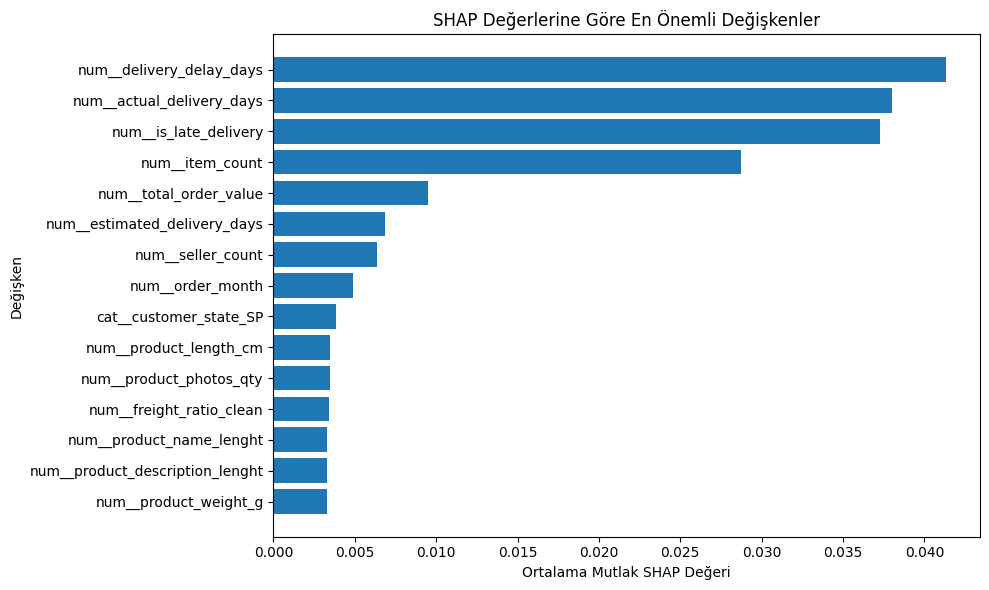

In [166]:
plt.figure(figsize=(10, 6))

top_shap = shap_importance.head(15).sort_values("mean_abs_shap")

plt.barh(top_shap["feature"], top_shap["mean_abs_shap"])
plt.title("SHAP Değerlerine Göre En Önemli Değişkenler")
plt.xlabel("Ortalama Mutlak SHAP Değeri")
plt.ylabel("Değişken")
plt.tight_layout()
plt.savefig("/content/outputs/shap_feature_importance.png")
plt.show()

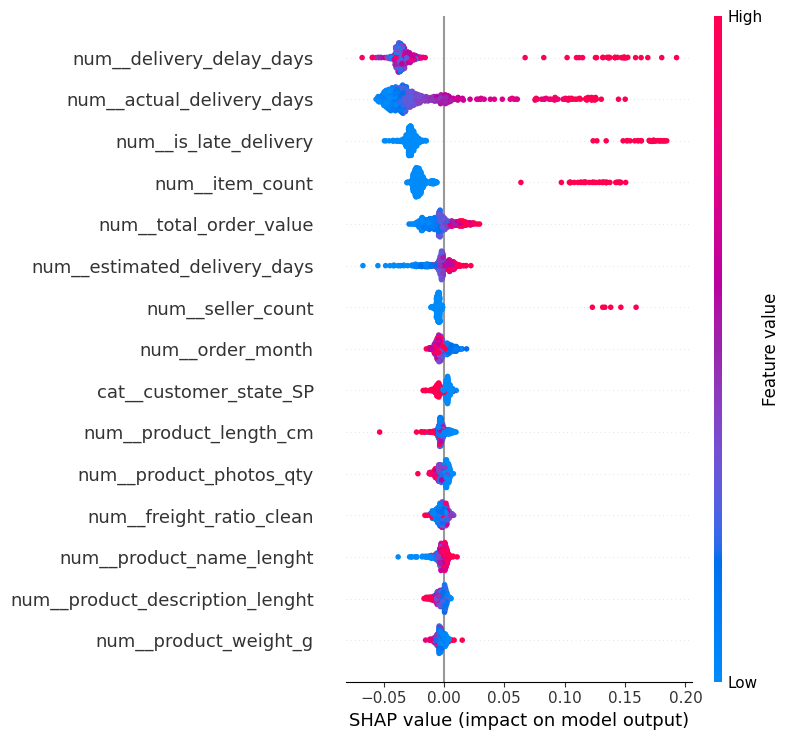

In [167]:
shap.summary_plot(
    shap_values_class1,
    X_test_sample,
    feature_names=feature_names,
    max_display=15,
    show=False
)

plt.tight_layout()
plt.savefig("/content/outputs/shap_summary_plot.png", bbox_inches="tight")
plt.show()

In [168]:
# İlk 500 test gözlemi için risk olasılıklarını alıyoruz
X_test_original_sample = X_test.iloc[:sample_size].copy()
sample_probabilities = best_model.predict_proba(X_test_original_sample)[:, 1]

# En yüksek riskli müşteriyi buluyoruz
high_risk_position = np.argmax(sample_probabilities)

print("Seçilen müşterinin tahmini düşük memnuniyet riski:", round(sample_probabilities[high_risk_position], 4))

Seçilen müşterinin tahmini düşük memnuniyet riski: 0.9507


In [169]:
local_explanation = pd.DataFrame({
    "feature": feature_names,
    "shap_value": shap_values_class1[high_risk_position]
})

local_explanation["abs_shap"] = local_explanation["shap_value"].abs()

local_top10 = local_explanation.sort_values("abs_shap", ascending=False).head(10)

local_top10

,feature,shap_value,abs_shap
3,num__is_late_delivery,0.172449,0.172449
2,num__delivery_delay_days,0.131581,0.131581
0,num__actual_delivery_days,0.123203,0.123203
46,cat__customer_state_RJ,0.015288,0.015288
10,num__order_month,0.012136,0.012136
8,num__item_count,-0.009341,0.009341
62,cat__product_category_name_english_bed_bath_table,0.005196,0.005196
4,num__total_order_value,0.004615,0.004615
5,num__freight_ratio_clean,-0.004236,0.004236
53,cat__customer_state_SP,0.004168,0.004168


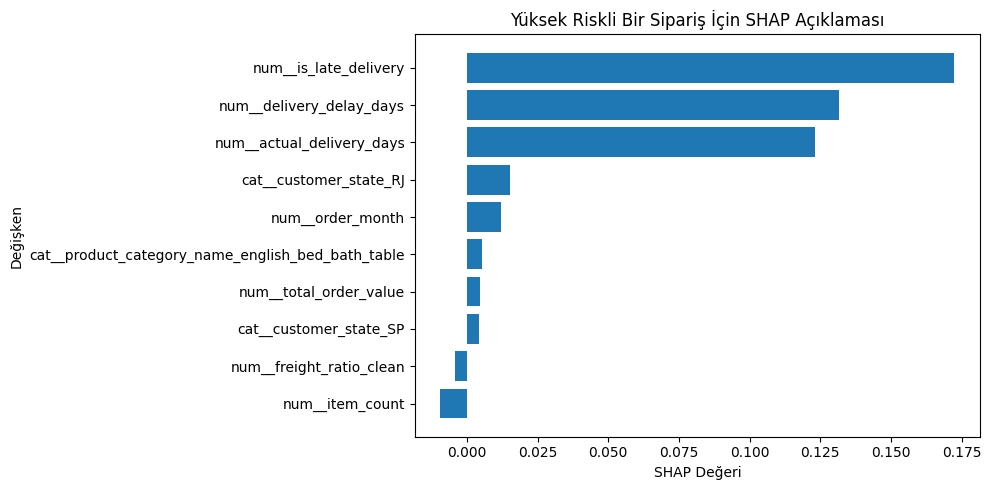

In [170]:
plt.figure(figsize=(10, 5))

local_top10_sorted = local_top10.sort_values("shap_value")

plt.barh(local_top10_sorted["feature"], local_top10_sorted["shap_value"])
plt.title("Yüksek Riskli Bir Sipariş İçin SHAP Açıklaması")
plt.xlabel("SHAP Değeri")
plt.ylabel("Değişken")
plt.tight_layout()
plt.savefig("/content/outputs/shap_local_explanation.png")
plt.show()

In [171]:
shap_importance.to_csv("/content/outputs/shap_feature_importance.csv", index=False)
local_top10.to_csv("/content/outputs/shap_local_explanation.csv", index=False)

print("SHAP sonuçları kaydedildi.")

SHAP sonuçları kaydedildi.


## Açıklanabilir Yapay Zeka Bulguları

Modelin kararlarını açıklamak için SHAP yöntemi kullanılmıştır. SHAP analizi, modelin düşük müşteri memnuniyeti tahminlerinde hangi değişkenlere daha fazla önem verdiğini göstermektedir.

Genel SHAP sonuçları, teslimat süresi, teslimat gecikmesi, sipariş değeri, kargo ücreti oranı, ödeme taksit sayısı, ürün kategorisi ve kampanya dönemi gibi değişkenlerin model kararlarında etkili olduğunu göstermektedir.

Bu bulgu işletme açısından önemlidir. Çünkü model yalnızca riskli müşterileri tahmin etmekle kalmamakta, aynı zamanda bu riskin hangi operasyonel nedenlerden kaynaklandığını da açıklamaktadır. Böylece şirket; teslimat gecikmelerini azaltma, yüksek kargo maliyetlerini optimize etme, belirli ürün kategorilerinde kalite kontrolü artırma ve kampanya dönemlerinde müşteri deneyimini iyileştirme gibi somut aksiyonlar alabilir.

## Genel Sonuç ve Yönetici Önerisi

Bu proje, e-ticaret siparişlerinde düşük müşteri memnuniyeti riskini tahmin etmek amacıyla geliştirilmiştir. Farklı veri kaynakları birleştirilmiş, işletme mantığına dayalı yeni değişkenler oluşturulmuş, makine öğrenmesi modelleri eğitilmiş ve sonuçlar finansal simülasyonla değerlendirilmiştir.

Analiz sonuçları, teslimat gecikmesi, kargo maliyeti, sipariş değeri, ödeme yapısı, ürün kategorisi ve kampanya dönemlerinin müşteri memnuniyetsizliği üzerinde etkili olabileceğini göstermektedir.

Model sonuçları doğrudan bir işletme kararına dönüştürülmüştür. Riskli müşterilere hedefli kupon verilmesi senaryosu test edilmiş ve farklı karar eşikleri için net finansal fayda hesaplanmıştır. Bu yaklaşım, şirketin pazarlama bütçesini rastgele kullanmak yerine veri odaklı ve hedefli şekilde kullanmasını sağlar.

Yönetici önerisi olarak, modelin müşteri deneyimi yönetimi sistemine entegre edilmesi önerilmektedir. Sipariş teslim süreci tamamlanmadan veya müşteri memnuniyetsizliği oluşmadan önce riskli siparişler belirlenerek proaktif destek, kupon veya telafi kampanyası uygulanabilir.

In [172]:
print("Proje başarıyla tamamlandı.")
print("Ana veri seti:", main_df.shape)
print("Model sonuçları:")
display(results)

print("Finansal simülasyon karşılaştırması:")
display(comparison_df)

print("Strateji karşılaştırması:")
display(strategy_comparison)

print("En önemli SHAP değişkenleri:")
display(shap_importance.head(10))

Proje başarıyla tamamlandı.
Ana veri seti: (99441, 52)
Model sonuçları:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.823290,0.369734,0.545157,0.440628,0.754672
1,Random Forest,0.860855,0.458238,0.493257,0.475103,0.763624


Finansal simülasyon karşılaştırması:


,Senaryo,Threshold,Kupon Verilen Müşteri,Kurtarılan Müşteri,Toplam Kupon Maliyeti,Net Finansal Fayda,Precision,Recall
0,Standart Threshold 0.50,0.5,2634.0,482.8,131700.0,13140.0,0.458238,0.493257
1,Optimize Edilmiş Threshold,0.7,1162.0,318.8,58100.0,37540.0,0.685886,0.325705


Strateji karşılaştırması:


,Strateji,Kupon Verilen Müşteri,Yakalanan Gerçek Riskli Müşteri,Kurtarılan Müşteri,Net Finansal Fayda
0,Rastgele Kupon,1162,138.0,55.2,-41540.0
1,Model Tabanlı Kupon,1162,797.0,318.8,37540.0


En önemli SHAP değişkenleri:


,feature,mean_abs_shap
2,num__delivery_delay_days,0.041352
0,num__actual_delivery_days,0.038001
3,num__is_late_delivery,0.037260
8,num__item_count,0.028728
4,num__total_order_value,0.009478
1,num__estimated_delivery_days,0.006836
9,num__seller_count,0.006341
10,num__order_month,0.004878
53,cat__customer_state_SP,0.003858
21,num__product_length_cm,0.003490
